# Linear Regression

### Let's go! First time implementing it!!

In [1]:
#Import all needed ones

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
print('Setup complete.')

Setup complete.


In [2]:
#lets create a random house price data for implementing LR
np.random.seed(42)
n = 500

size     = np.random.randint(500, 4000, n).astype(float)
bedrooms = np.random.randint(1, 6, n).astype(float)
age      = np.random.randint(0, 51, n).astype(float)
dist     = np.random.uniform(1, 30, n)

price = (150 * size +
         20_000 * bedrooms -
         1_000 * age -
         3_000 * dist +
         np.random.normal(0, 30_000, n) +
         100_000)
price = np.maximum(price, 50_000)

df = pd.DataFrame({
    'size_sqft': size,
    'bedrooms':  bedrooms,
    'age_years': age,
    'dist_km':   dist,
    'price':     price
})

print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (500, 5)


,size_sqft,bedrooms,age_years,dist_km,price
0,3674.0,4.0,23.0,15.369248,623651.577987
1,1360.0,2.0,30.0,20.963669,201796.770043
2,1794.0,3.0,5.0,13.609993,356715.116571
3,1630.0,4.0,1.0,8.145659,445639.877573
4,1595.0,5.0,19.0,24.753967,299406.286328


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   size_sqft  500 non-null    float64
 1   bedrooms   500 non-null    float64
 2   age_years  500 non-null    float64
 3   dist_km    500 non-null    float64
 4   price      500 non-null    float64
dtypes: float64(5)
memory usage: 19.7 KB


In [4]:
#stats
df.describe()

,size_sqft,bedrooms,age_years,dist_km,price
count,500.00000,500.000000,500.000000,500.000000,500.000000
mean,2319.38400,3.052000,25.142000,16.075263,434761.821337
std,1003.67328,1.462043,14.921768,8.659981,159570.316620
min,501.00000,1.000000,0.000000,1.143259,78803.473309
25%,1478.75000,2.000000,11.000000,8.114071,304694.477184
50%,2297.50000,3.000000,25.000000,16.697162,431677.183422
75%,3208.00000,4.000000,37.000000,23.634054,568986.538300
max,3999.00000,5.000000,50.000000,29.982998,803093.368578


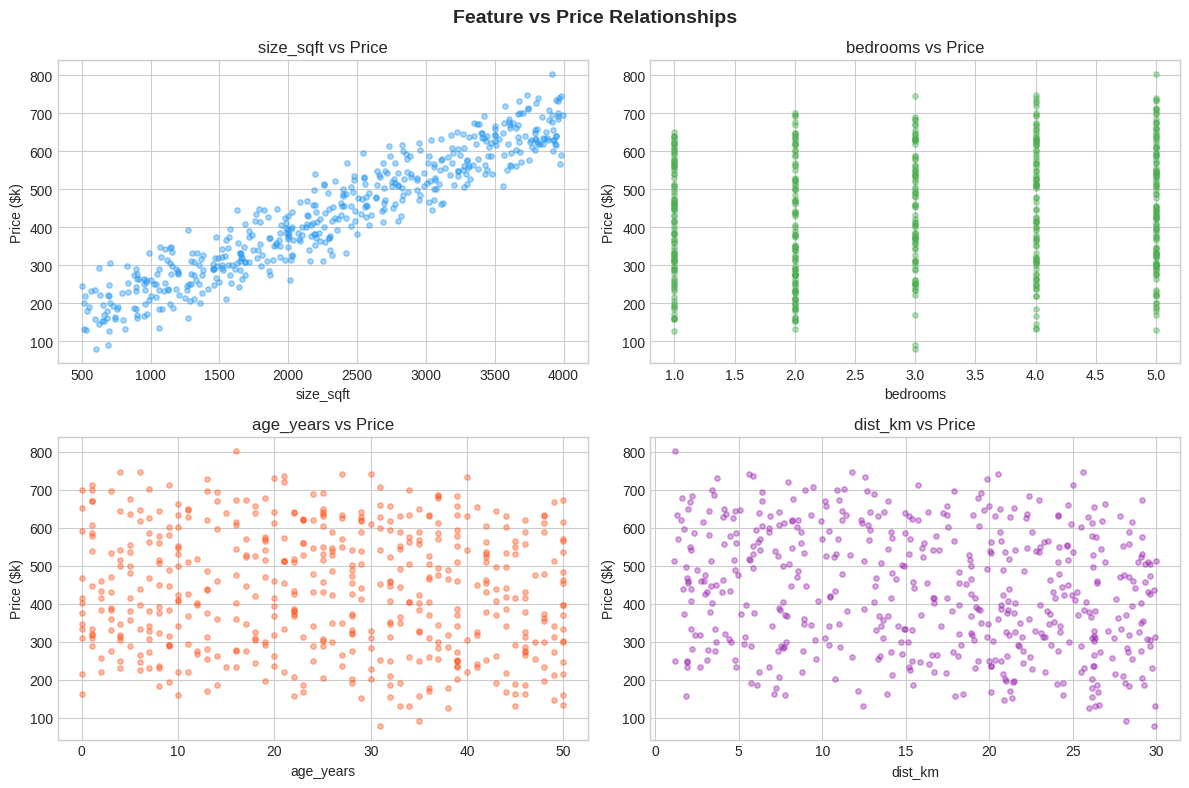

In [5]:
#Lets visualise the data
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Feature vs Price Relationships', fontsize=14, fontweight='bold')

features = ['size_sqft', 'bedrooms', 'age_years', 'dist_km']
colors   = ['#2196F3', '#4CAF50', '#FF5722', '#9C27B0']

for ax, feat, color in zip(axes.flat, features, colors):
    ax.scatter(df[feat], df['price'] / 1000, alpha=0.4, color=color, s=15)
    ax.set_xlabel(feat)
    ax.set_ylabel('Price ($k)')
    ax.set_title(f'{feat} vs Price')

plt.tight_layout()
plt.show()

In [8]:
# Simple Linear Regression from scratch using OLS.
# As seen in the ploted fig above price vs sqft is what we will take for this
# Goal -> find the optimal slope (β₁) and intercept (β₀) that minimise the total squared error between actual and predicted prices.

x = df['size_sqft'].values
y = df['price'].values

x_mean = np.mean(x)
y_mean = np.mean(y)

numerator   = np.sum((x - x_mean) * (y - y_mean))
denominator = np.sum((x - x_mean) ** 2)

beta_1 = numerator / denominator
beta_0 = y_mean - beta_1 * x_mean #OLS final formulae.

print(f'Intercept  β₀ = ${beta_0:,.2f}')
print(f'Slope      β₁ = ${beta_1:.4f} per sq ft')
print(f'\nInterpretation: for every additional sq ft, price increases by ${beta_1:.2f}')

# that means y^i = β₀ + β₁Xi L.R equation

Intercept  β₀ = $85,481.52
Slope      β₁ = $150.5918 per sq ft

Interpretation: for every additional sq ft, price increases by $150.59


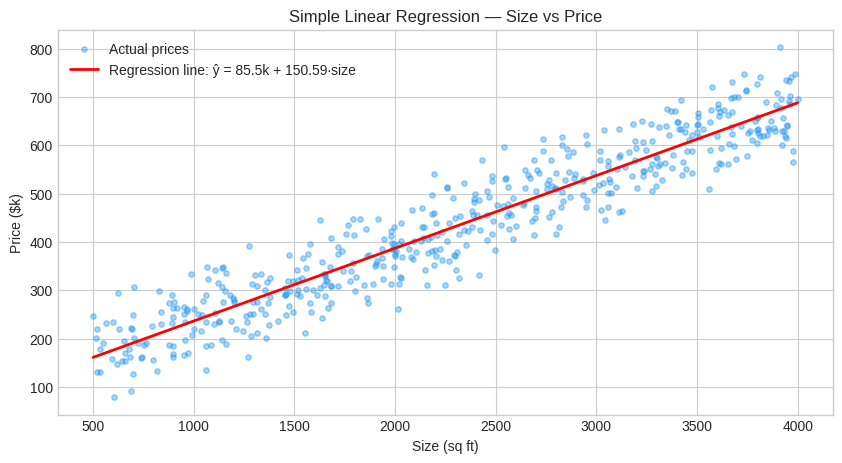

In [9]:
#Lets plot it
y_pred_simple = beta_0 + beta_1 * x

plt.figure(figsize=(10, 5))
plt.scatter(x, y / 1000, alpha=0.4, s=15, color='#2196F3', label='Actual prices')

x_line = np.linspace(x.min(), x.max(), 100)
y_line = beta_0 + beta_1 * x_line

plt.plot(x_line, y_line / 1000, color='red', linewidth=2,
         label=f'Regression line: ŷ = {beta_0/1000:.1f}k + {beta_1:.2f}·size')
plt.xlabel('Size (sq ft)')
plt.ylabel('Price ($k)')
plt.title('Simple Linear Regression — Size vs Price')
plt.legend()
plt.show()

In [10]:
#Lets find the model performance now

y_bar = np.mean(y)

TSS = np.sum((y - y_bar) ** 2)
RSS = np.sum((y - y_pred_simple) ** 2)
ESS = np.sum((y_pred_simple - y_bar) ** 2)

R2     = 1 - (RSS / TSS)
n      = len(y)
k      = 1  # one feature
Adj_R2 = 1 - (1 - R2) * (n - 1) / (n - k - 1)

print('=' * 50)
print('  EXPLORATORY PERFORMANCE METRICS')
print('=' * 50)
print(f'  TSS (Total SS)      : {TSS:,.0f}')
print(f'  ESS (Explained SS)  : {ESS:,.0f}')
print(f'  RSS (Residual SS)   : {RSS:,.0f}')
print(f'  TSS = ESS + RSS?    : {abs(TSS - (ESS + RSS)) < 1}')
print(f'  R²                  : {R2:.4f}')
print(f'  Adjusted R²         : {Adj_R2:.4f}')
print('=' * 50)
print(f'\n→ The model explains {R2*100:.1f}% of the variance in house prices using size alone.')

  EXPLORATORY PERFORMANCE METRICS
  TSS (Total SS)      : 12,705,880,287,093
  ESS (Explained SS)  : 11,399,561,282,167
  RSS (Residual SS)   : 1,306,319,004,926
  TSS = ESS + RSS?    : True
  R²                  : 0.8972
  Adjusted R²         : 0.8970

→ The model explains 89.7% of the variance in house prices using size alone.


In [11]:
# Multiple Linear Regression. Considering all 4 features using sklearn
# sklearn does the same OLS under the hood, just handles multiple features at once

X = df[['size_sqft', 'bedrooms', 'age_years', 'dist_km']].values
y = df['price'].values

# Split into training (80%) and test (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training samples : {X_train.shape[0]}')
print(f'Test samples     : {X_test.shape[0]}')

Training samples : 400
Test samples     : 100


In [12]:
# Fit Multiple Linear Regression
model = LinearRegression()
model.fit(X_train, y_train)

feature_names = ['size_sqft', 'bedrooms', 'age_years', 'dist_km']

print(f'Intercept : ${model.intercept_:,.2f}')
print()
print('Coefficients:')
for name, coef in zip(feature_names, model.coef_):
    direction = '▲' if coef > 0 else '▼'
    print(f'  {name:<15} {direction}  ${coef:,.2f}')

Intercept : $95,697.17

Coefficients:
  size_sqft       ▲  $150.63
  bedrooms        ▲  $21,242.65
  age_years       ▼  $-1,036.01
  dist_km         ▼  $-3,078.91


In [13]:
# Predict on test set, model has never seen these 100 houses
y_pred_test = model.predict(X_test)

# Compute all metrics from scratch
residuals = y_test - y_pred_test

MSE  = np.mean(residuals ** 2)
RMSE = np.sqrt(MSE)
MAE  = np.mean(np.abs(residuals))
MAPE = np.mean(np.abs(residuals / y_test)) * 100

print('=' * 55)
print('  PREDICTIVE PERFORMANCE METRICS (Test Set)')
print('=' * 55)
print(f'  MSE         : ${MSE:>14,.0f}')
print(f'  RMSE        : ${RMSE:>14,.0f}')
print(f'  MAE         : ${MAE:>14,.0f}')
print(f'  MAPE        : {MAPE:.2f}%')
print('=' * 55)
print(f'\n→ On average, predictions are off by ${MAE:,.0f} ({MAPE:.1f}%)')

  PREDICTIVE PERFORMANCE METRICS (Test Set)
  MSE         : $ 1,063,233,735
  RMSE        : $        32,607
  MAE         : $        26,416
  MAPE        : 6.72%

→ On average, predictions are off by $26,416 (6.7%)


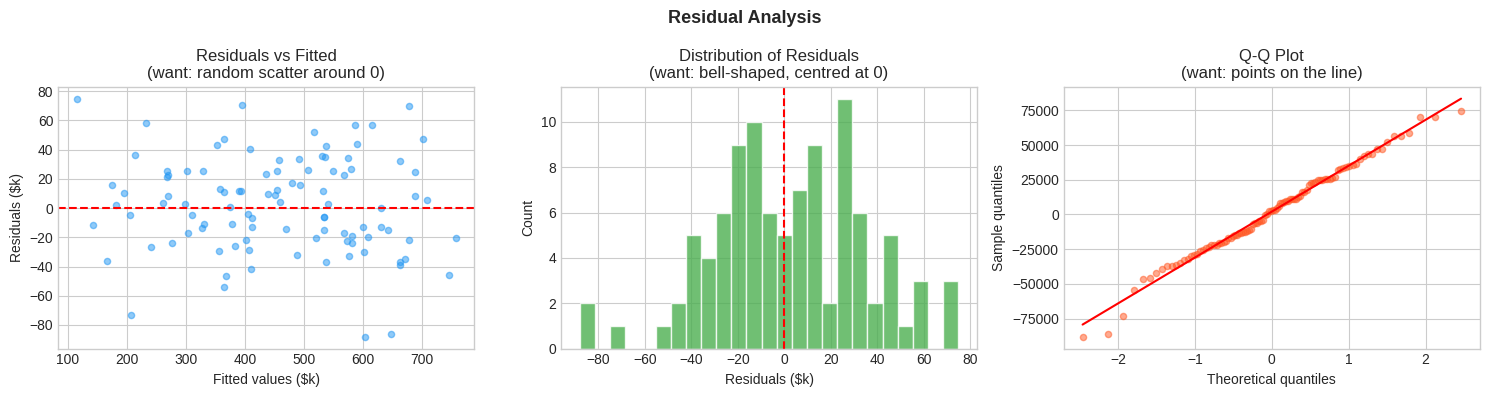

In [14]:
from scipy import stats

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Residual Analysis', fontsize=13, fontweight='bold')

# 1. Residuals vs Fitted
ax = axes[0]
ax.scatter(y_pred_test / 1000, residuals / 1000, alpha=0.5, s=20, color='#2196F3')
ax.axhline(0, color='red', linewidth=1.5, linestyle='--')
ax.set_xlabel('Fitted values ($k)')
ax.set_ylabel('Residuals ($k)')
ax.set_title('Residuals vs Fitted\n(want: random scatter around 0)')

# 2. Distribution of residuals
ax = axes[1]
ax.hist(residuals / 1000, bins=25, color='#4CAF50', edgecolor='white', alpha=0.8)
ax.axvline(0, color='red', linewidth=1.5, linestyle='--')
ax.set_xlabel('Residuals ($k)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Residuals\n(want: bell-shaped, centred at 0)')

# 3. Q-Q plot
ax = axes[2]
(osm, osr), (slope, intercept, r) = stats.probplot(residuals, dist='norm')
ax.scatter(osm, osr, alpha=0.5, s=20, color='#FF5722')
ax.plot(osm, slope * np.array(osm) + intercept, color='red', linewidth=1.5)
ax.set_xlabel('Theoretical quantiles')
ax.set_ylabel('Sample quantiles')
ax.set_title('Q-Q Plot\n(want: points on the line)')

plt.tight_layout()
plt.show()

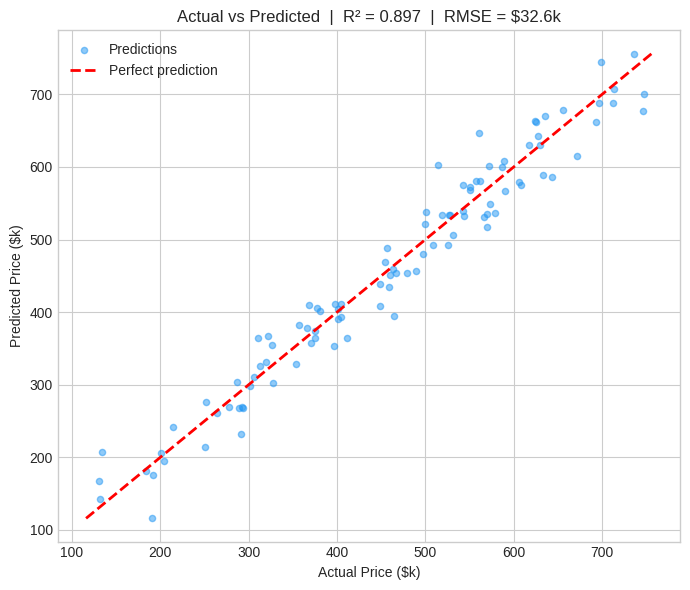

In [15]:
# Final check: how close are predictions to reality visually
y_pred_test = model.predict(X_test)

plt.figure(figsize=(7, 6))
plt.scatter(y_test / 1000, y_pred_test / 1000,
            alpha=0.5, s=20, color='#2196F3', label='Predictions')

min_val = min(y_test.min(), y_pred_test.min()) / 1000
max_val = max(y_test.max(), y_pred_test.max()) / 1000
plt.plot([min_val, max_val], [min_val, max_val],
         'r--', linewidth=2, label='Perfect prediction')

plt.xlabel('Actual Price ($k)')
plt.ylabel('Predicted Price ($k)')
plt.title(f'Actual vs Predicted  |  R² = {R2:.3f}  |  RMSE = ${RMSE/1000:.1f}k')
plt.legend()
plt.tight_layout()
plt.show()

## Summary

| Metric | Value | Interpretation |
|--------|-------|----------------|
| R² | 0.897 | Model explains 89.7% of price variance |
| Adjusted R² | 0.896 | Confirmed all 4 features genuinely contribute |
| RMSE | 32,607 dollars | Typical error, large mistakes weighted more |
| MAE | 26,416 dollars| Average prediction is off by $26,416 |
| MAPE | 6.72% | Predictions are within 6.7% of actual price |

### Key Takeaways
- OLS recovers true coefficients even through noisy data
- Size is the strongest predictor $150 per sq ft
- All 4 features genuinely contribute Adj R² confirms this
- Residuals are random and normally distributed model assumptions satisfied
- 6.7% average error is strong for a 4-feature linear model

### Next Steps
- Apply same techniques to real data -> California Housing dataset
